# Pytorch

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

## Making Dataset class for handwritten letters

In [2]:
class AZDataset(Dataset):
    def __init__(self, csv_file):
        data = pd.read_csv(csv_file, header=None)
        
        self.labels = torch.tensor(data.iloc[:, 0].values, dtype=torch.long)
        
        pixels = data.iloc[:, 1:].values
        
        pixels = pixels / 255.0
        pixels = (pixels - 0.5) / 0.5
        
        self.features = torch.tensor(pixels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

## Making DataLoader for training and testing

In [3]:
full_dataset = AZDataset('A_Z Handwritten Data.csv')

train_size = int(0.75 * len(full_dataset))
test_size = len(full_dataset) - train_size
trainset, testset = random_split(full_dataset, [train_size, test_size])

batch_size = 256

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

label_mapping = [chr(i) for i in range(ord('A'), ord('Z') + 1)]

## Calculating size of train and test sets

In [4]:
input_size = torch.numel(trainset[0][0])
output_size = len(label_mapping)

print(f"Вхідний розмір: {input_size}")
print(f"Вихідний розмір: {output_size}")

Вхідний розмір: 784
Вихідний розмір: 26


## Creating a neural network model

In [19]:
class AZModel(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.flatten = nn.Flatten()
        
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            
            nn.Linear(256, output_size)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AZModel(input_size, output_size).to(device)
print(model)

AZModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Linear(in_features=256, out_features=26, bias=True)
  )
)


## Adjusting giperparameters

In [29]:
learning_rate = 1e-3
epochs = 15

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

## Function for train loop

In [21]:
def train_loop(dataloader, model, loss_fn, optimizer, epoch):
    model.train()
    
    tqdm_loader = tqdm(dataloader, unit="batch", desc=f"Epoch {epoch}", total=len(dataloader))
    for batch, (X, y) in enumerate(tqdm_loader):
        X, y = X.to(device), y.to(device)
        
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 1000 == 0:
            tqdm_loader.set_postfix(loss=loss.item())


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

## Training the model

In [30]:
for epoch in range(1, epochs + 1):
    train_loop(train_loader, model, loss_fn, optimizer, epoch)
    test_loop(test_loader, model, loss_fn)

Epoch 1: 100%|██████████| 1092/1092 [00:09<00:00, 120.81batch/s, loss=0.295]


Test Error: 
 Accuracy: 93.0%, Avg loss: 0.289494 



Epoch 2: 100%|██████████| 1092/1092 [00:08<00:00, 125.73batch/s, loss=0.247]


Test Error: 
 Accuracy: 93.4%, Avg loss: 0.272541 



Epoch 3: 100%|██████████| 1092/1092 [00:08<00:00, 134.66batch/s, loss=0.256]


...

Test Error: 
 Accuracy: 95.8%, Avg loss: 0.168709 



Epoch 14: 100%|██████████| 1092/1092 [00:08<00:00, 130.37batch/s, loss=0.15]


Test Error: 
 Accuracy: 95.9%, Avg loss: 0.164201 



Epoch 15: 100%|██████████| 1092/1092 [00:07<00:00, 141.12batch/s, loss=0.134]


Test Error: 
 Accuracy: 96.1%, Avg loss: 0.159576 



## Show accuracy of the model on test set

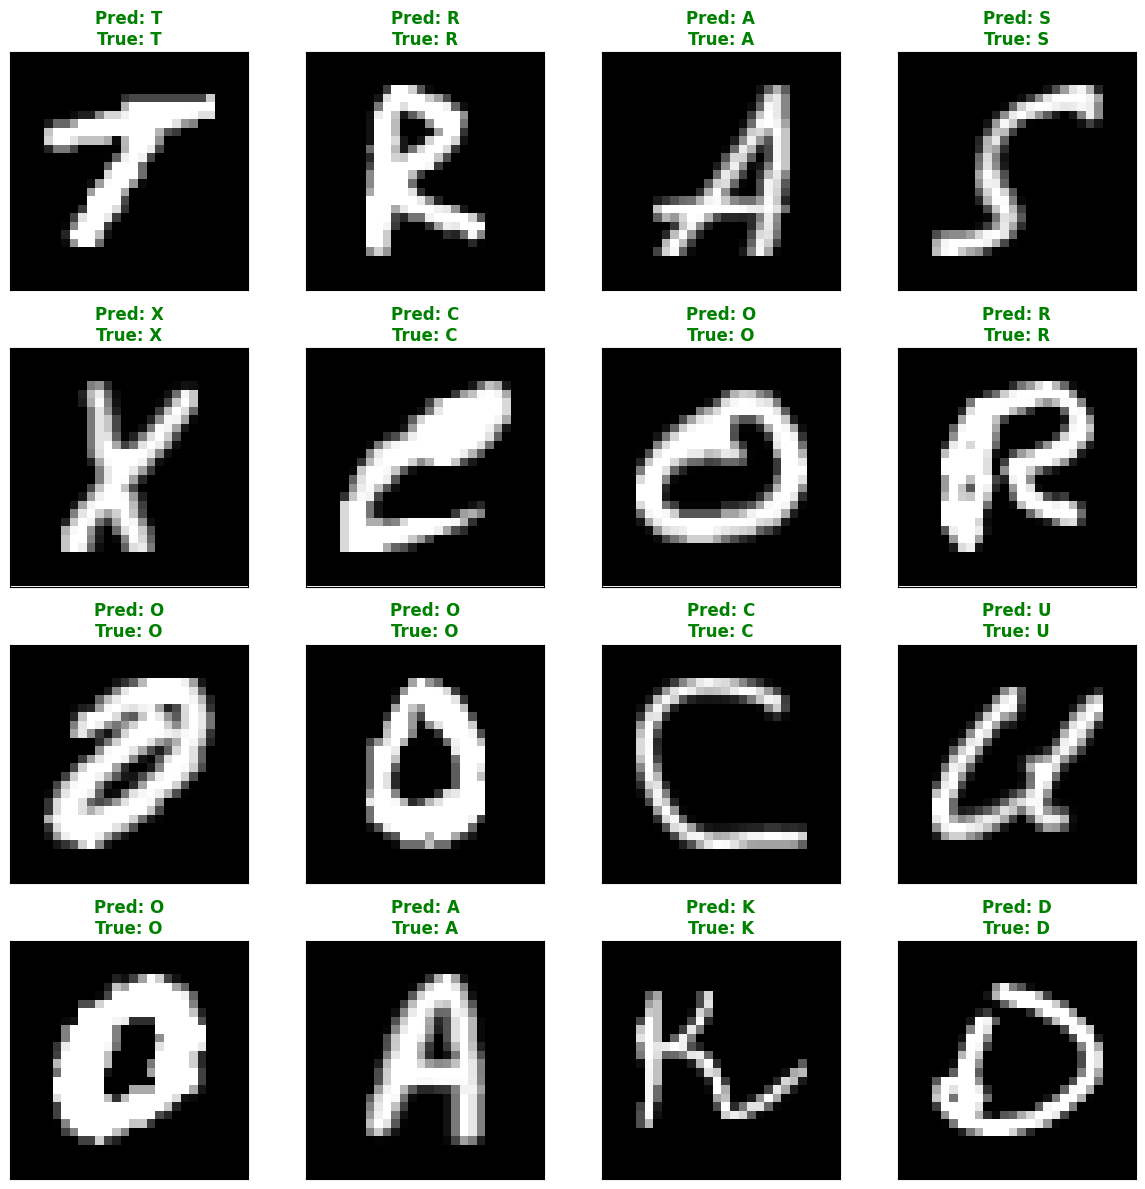

In [41]:
model.eval()

fig = plt.figure(figsize=(12, 12)) 

with torch.no_grad():
    for i in range(16):
        idx = random.randint(0, len(testset) - 1)
        image, true_label_tensor = testset[idx]

        img_for_model = image.unsqueeze(0).to(device)
        pred_logits = model(img_for_model)
        pred_label_idx = pred_logits.argmax(1).item()
        
        true_char = label_mapping[true_label_tensor.item()]
        pred_char = label_mapping[pred_label_idx]
        
        display_img = image.cpu().numpy().reshape(28, 28)
        display_img = (display_img * 0.5) + 0.5
        
        # 3. Кажемо matplotlib, що сітка тепер 4x4
        ax = fig.add_subplot(4, 4, i+1, xticks=[], yticks=[])
        ax.imshow(display_img, cmap='gray')

        color = "green" if true_char == pred_char else "red"
        ax.set_title(f"Pred: {pred_char}\nTrue: {true_char}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()